In [1]:
# In this section, we will develop an intuition for the SMOTE by applying it to an imbalanced binary classification problem.
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE
from matplotlib import pyplot
import matplotlib.pyplot as plt
from numpy import where
import pandas as pd
import numpy as np
import os

# define dataset
#df = pd.read_csv("C:\\Users\\olufe\\projects\\Journal\\dataset\\HomeA_unsupervised_sim_combined_shuffled.csv")
#X, y = make_classification(n_samples=10000, n_features=2, n_redundant=0,
#	n_clusters_per_class=1, weights=[0.99], flip_y=0, random_state=1)

In [2]:
# Option A
# Function to read data from the CSV file and split it into X and y
def read_data_from_csv(csv_file_path):
    data = pd.read_csv(csv_file_path)
    X = data.iloc[:, :-1]  # All columns except the last one are input features
    y = data.iloc[:, -1]   # The last column is the target variable
    return X, y

# Define the CSV file path
csv_file_path = r"C:\Users\olufe\projects\Journal\dataset\HomeA_unsupervised_sim_combined_data.csv"

# Read the data from the CSV file
X, y = read_data_from_csv(csv_file_path)

# If you want to generate the data using make_classification (not using CSV), uncomment the following line
# X, y = make_classification(n_samples=10000, n_features=2, n_redundant=0, n_clusters_per_class=1, weights=[0.99], flip_y=0, random_state=1)

# Print some information about the data
print("X shape:", X.shape)
print("y shape:", y.shape)

# Now, you have X and y filled with the data from the CSV file or generated using make_classification.


X shape: (35330, 1380)
y shape: (35330,)


In [3]:
# File path
csv_file_path = r"C:\Users\olufe\projects\Journal\dataset\HomeA_unsupervised_sim_combined_data.csv"

# Load the data from the CSV file
data = pd.read_csv(csv_file_path)

# Extract features (X) and target labels (y) from the loaded data
X = data.drop(columns=["Label"])  # Replace "target_column_name" with the actual column name for the target variable
y = data["Label"]  # Replace "target_column_name" with the actual column name for the target variable

# Print the extracted values of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (35330, 1380)
y shape: (35330,)


In [4]:
# summarize class distribution
counter = Counter(y)
print(counter)

Counter({0: 35186, 1: 144})


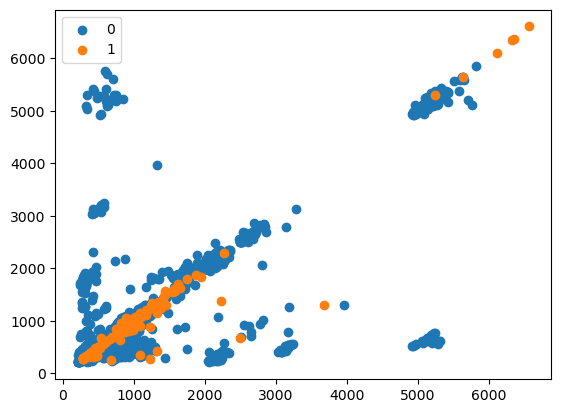

In [5]:
# Plot scatter points for each label in y
unique_labels = y.unique()
for label in unique_labels:
    row_ix = y[y == label].index
    plt.scatter(X.loc[row_ix, X.columns[0]], X.loc[row_ix, X.columns[1]], label=str(label))
plt.legend()
plt.show()

# scatter plot of examples by class label
#for label, _ in counter.items():
#	row_ix = where(y == label)[0]
#	pyplot.scatter(X[row_ix, 0], X[row_ix, 1], label=str(label))
#pyplot.legend()
#pyplot.show()

# Oversample and plot imbalanced dataset with SMOTE

In [6]:
# summarize class distribution
counter = Counter(y)
print(counter)

Counter({0: 35186, 1: 144})


In [7]:
# transform the dataset
oversample = SMOTE()
X, y = oversample.fit_resample(X, y)

In [8]:
# summarize the new class distribution
counter = Counter(y)
print(counter)

Counter({0: 35186, 1: 35186})


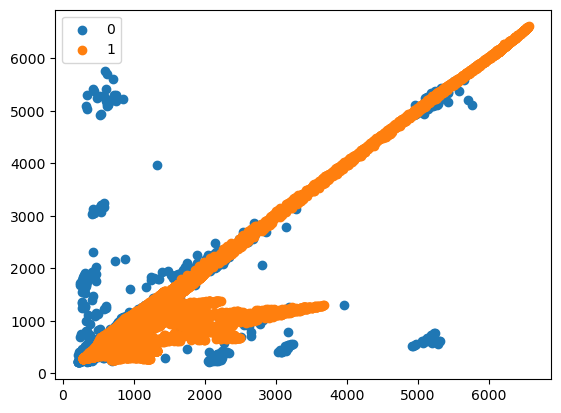

In [9]:
# Plot scatter points for each label in y
unique_labels = y.unique()
for label in unique_labels:
    row_ix = y[y == label].index
    plt.scatter(X.loc[row_ix, X.columns[0]], X.loc[row_ix, X.columns[1]], label=str(label))
plt.legend()
plt.show()

# scatter plot of examples by class label
#for label, _ in counter.items():
# row_ix = where(y == label)[0]
# pyplot.scatter(X[row_ix, 0], X[row_ix, 1], label=str(label))
#pyplot.legend()
#pyplot.show()

# Oversample with SMOTE and random undersample for imbalanced dataset

In [10]:
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from matplotlib import pyplot
from numpy import where

# define dataset
#X, y = make_classification(n_samples=10000, n_features=2, n_redundant=0,
#	n_clusters_per_class=1, weights=[0.99], flip_y=0, random_state=1)
########################################################
# File path
csv_file_path = r"C:\Users\olufe\projects\Journal\dataset\HomeA_unsupervised_sim_combined_data.csv"

# Load the data from the CSV file
data = pd.read_csv(csv_file_path)

# Extract features (X) and target labels (y) from the loaded data
X = data.drop(columns=["Label"])  # Replace "target_column_name" with the actual column name for the target variable
y = data["Label"]  # Replace "target_column_name" with the actual column name for the target variable

# Print the extracted values of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)
########################################################

X shape: (35330, 1380)
y shape: (35330,)


In [11]:
# summarize class distribution
counter = Counter(y)
print(counter)

Counter({0: 35186, 1: 144})


In [12]:
# define pipeline
over = SMOTE(sampling_strategy=0.1)
under = RandomUnderSampler(sampling_strategy=0.5)
steps = [('o', over), ('u', under)]
pipeline = Pipeline(steps=steps)

In [13]:
# transform the dataset
X, y = pipeline.fit_resample(X, y)

In [14]:
# summarize the new class distribution
counter = Counter(y)
print(counter)

Counter({0: 7036, 1: 3518})


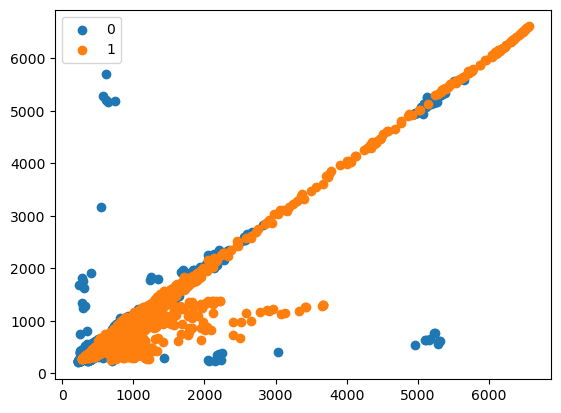

In [15]:
# Plot scatter points for each label in y
unique_labels = y.unique()
for label in unique_labels:
    row_ix = y[y == label].index
    plt.scatter(X.loc[row_ix, X.columns[0]], X.loc[row_ix, X.columns[1]], label=str(label))
plt.legend()
plt.show()

# scatter plot of examples by class label
#for label, _ in counter.items():
#	row_ix = where(y == label)[0]
#	pyplot.scatter(X[row_ix, 0], X[row_ix, 1], label=str(label))
#pyplot.legend()
#pyplot.show()

# SMOTE for Classification

In [16]:
# decision tree evaluated on imbalanced dataset
from numpy import mean
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.tree import DecisionTreeClassifier

# define dataset
#X, y = make_classification(n_samples=10000, n_features=2, n_redundant=0,
#	n_clusters_per_class=1, weights=[0.99], flip_y=0, random_state=1)
######################################################################################
# File path
csv_file_path = r"C:\Users\olufe\projects\Journal\dataset\HomeA_unsupervised_sim_combined_data.csv"

# Load the data from the CSV file
data = pd.read_csv(csv_file_path)

# Extract features (X) and target labels (y) from the loaded data
X = data.drop(columns=["Label"])  # Replace "target_column_name" with the actual column name for the target variable
y = data["Label"]  # Replace "target_column_name" with the actual column name for the target variable

# Print the extracted values of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (35330, 1380)
y shape: (35330,)


In [17]:
#from sklearn.ensemble import IsolationForest
#X = [[-1.1], [0.3], [0.5], [100]]
#clf = IsolationForest(random_state=0).fit(X)
#clf.predict([[0.1], [0], [90]])
#array([ 1,  1, -1])

In [18]:
from sklearn.ensemble import IsolationForest
# define model
#clf = IsolationForest(random_state=0).fit(X)
model = IsolationForest(random_state=0).fit(X)
#model = DecisionTreeClassifier()

# evaluate pipeline
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
scores = cross_val_score(model, X, y, scoring='roc_auc', cv=cv, n_jobs=-1)
print('Mean ROC AUC: %.3f' % mean(scores))

Mean ROC AUC: 0.223


In [20]:
from sklearn.ensemble import RandomForestRegressor

#X, y = make_regression(n_features=4, n_informative=2,
#                        random_state=0, shuffle=False)
#regr = RandomForestRegressor(max_depth=2, random_state=0)
model = RandomForestRegressor(max_depth=5, random_state=0)
#regr.fit(X, y)
#RandomForestRegressor(...)
# result @ max_depth=2, random_state=42 ~ Mean ROC AUC: 0.584

# evaluate pipeline
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
scores = cross_val_score(model, X, y, scoring='roc_auc', cv=cv, n_jobs=-1)
print('Mean ROC AUC: %.3f' % mean(scores))

Mean ROC AUC: 0.669


In [27]:
# decision tree evaluated on imbalanced dataset with SMOTE oversampling
from numpy import mean
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import IsolationForest
# define dataset
#X, y = make_classification(n_samples=10000, n_features=2, n_redundant=0,
#	n_clusters_per_class=1, weights=[0.99], flip_y=0, random_state=1)
# File path
csv_file_path = r"C:\Users\olufe\projects\Journal\dataset\HomeA_unsupervised_sim_combined_data.csv"

# Load the data from the CSV file
data = pd.read_csv(csv_file_path)

# Extract features (X) and target labels (y) from the loaded data
X = data.drop(columns=["Label"])  # Replace "target_column_name" with the actual column name for the target variable
y = data["Label"]  # Replace "target_column_name" with the actual column name for the target variable

# Print the extracted values of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (35330, 1380)
y shape: (35330,)


In [29]:
# values to evaluate
k_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
for k in k_values:
	# define pipeline
#	model = DecisionTreeClassifier()
	model = IsolationForest(contamination=0.15, random_state=42)
	model.fit(X)
	over = SMOTE(sampling_strategy=0.1, k_neighbors=k)
	under = RandomUnderSampler(sampling_strategy=0.5)
#    under = RandomUnderSampler(sampling_strategy=0.5)
	steps = [('over', over), ('under', under), ('model', model)]
	pipeline = Pipeline(steps=steps)
	# evaluate pipeline
	cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
	scores = cross_val_score(pipeline, X, y, scoring='roc_auc', cv=cv, n_jobs=-1)
	score = mean(scores)
	print('> k=%d, Mean ROC AUC: %.3f' % (k, score))

C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


> k=1, Mean ROC AUC: 0.236


C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


> k=2, Mean ROC AUC: 0.238


C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


> k=3, Mean ROC AUC: 0.238


C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


> k=4, Mean ROC AUC: 0.238


C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


KeyboardInterrupt: 

In [26]:
# define pipeline
#steps = [('over', SMOTE()), ('model', DecisionTreeClassifier())]
steps = [('over', SMOTE()), ('model', IsolationForest(contamination=0.15, random_state=42).fit(X))]

pipeline = Pipeline(steps=steps)

# evaluate pipeline
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
scores = cross_val_score(pipeline, X, y, scoring='roc_auc', cv=cv, n_jobs=-1)
print('Mean ROC AUC: %.3f' % mean(scores))

C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


Mean ROC AUC: nan


C:\Users\olufe\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:372: FitFailedWarning: 
15 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\olufe\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\olufe\anaconda3\lib\site-packages\imblearn\pipeline.py", line 297, in fit
    self._final_estimator.fit(Xt, yt, **fit_params_last_step)
  File "C:\Users\olufe\anaconda3\lib\site-packages\sklearn\ensemble\_iforest.py", line 258, in fit
    X = self._validate_data(X, accept_sparse=["csc"])
  Fil

In [23]:
# decision tree  on imbalanced dataset with SMOTE oversampling and random undersampling
from numpy import mean
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# define dataset
#X, y = make_classification(n_samples=10000, n_features=2, n_redundant=0,
#	n_clusters_per_class=1, weights=[0.99], flip_y=0, random_state=1)
###################################################################
# File path
csv_file_path = r"C:\Users\olufe\projects\Journal\dataset\HomeA_unsupervised_sim_combined_data.csv"

# Load the data from the CSV file
data = pd.read_csv(csv_file_path)

# Extract features (X) and target labels (y) from the loaded data
X = data.drop(columns=["Label"])  # Replace "target_column_name" with the actual column name for the target variable
y = data["Label"]  # Replace "target_column_name" with the actual column name for the target variable

# Print the extracted values of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (35330, 1380)
y shape: (35330,)


In [24]:
# define pipeline
model = DecisionTreeClassifier()
over = SMOTE(sampling_strategy=0.1)
under = RandomUnderSampler(sampling_strategy=0.5)
steps = [('over', over), ('under', under), ('model', model)]
pipeline = Pipeline(steps=steps)

# evaluate pipeline
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
scores = cross_val_score(pipeline, X, y, scoring='roc_auc', cv=cv, n_jobs=-1)
print('Mean ROC AUC: %.3f' % mean(scores))

Mean ROC AUC: 0.734


In [25]:
# grid search k value for SMOTE oversampling for imbalanced classification
from numpy import mean
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# define dataset
#X, y = make_classification(n_samples=10000, n_features=2, n_redundant=0,
#	n_clusters_per_class=1, weights=[0.99], flip_y=0, random_state=1)
######################################################################################
# File path
csv_file_path = r"C:\Users\olufe\projects\Journal\dataset\HomeA_unsupervised_sim_combined_data.csv"

# Load the data from the CSV file
data = pd.read_csv(csv_file_path)

# Extract features (X) and target labels (y) from the loaded data
X = data.drop(columns=["Label"])  # Replace "target_column_name" with the actual column name for the target variable
y = data["Label"]  # Replace "target_column_name" with the actual column name for the target variable

# Print the extracted values of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (35330, 1380)
y shape: (35330,)


In [26]:
# values to evaluate
k_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
for k in k_values:
	# define pipeline
	model = DecisionTreeClassifier()
	over = SMOTE(sampling_strategy=0.1, k_neighbors=k)
	under = RandomUnderSampler(sampling_strategy=0.5)
#    under = RandomUnderSampler(sampling_strategy=0.5)
	steps = [('over', over), ('under', under), ('model', model)]
	pipeline = Pipeline(steps=steps)
	# evaluate pipeline
	cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
	scores = cross_val_score(pipeline, X, y, scoring='roc_auc', cv=cv, n_jobs=-1)
	score = mean(scores)
	print('> k=%d, Mean ROC AUC: %.3f' % (k, score))

> k=1, Mean ROC AUC: 0.716
> k=2, Mean ROC AUC: 0.730
> k=3, Mean ROC AUC: 0.730
> k=4, Mean ROC AUC: 0.737
> k=5, Mean ROC AUC: 0.748
> k=6, Mean ROC AUC: 0.749
> k=7, Mean ROC AUC: 0.747
> k=8, Mean ROC AUC: 0.744
> k=9, Mean ROC AUC: 0.757
> k=10, Mean ROC AUC: 0.752


In [28]:
# values to evaluate
k_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
for k in k_values:
	# define pipeline
	model = DecisionTreeClassifier()
	over = SMOTE(sampling_strategy=0.2, k_neighbors=k)
	under = RandomUnderSampler(sampling_strategy=0.5)
#    under = RandomUnderSampler(sampling_strategy=0.5)
	steps = [('over', over), ('under', under), ('model', model)]
	pipeline = Pipeline(steps=steps)
	# evaluate pipeline
	cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
	scores = cross_val_score(pipeline, X, y, scoring='roc_auc', cv=cv, n_jobs=-1)
	score = mean(scores)
	print('> k=%d, Mean ROC AUC: %.3f' % (k, score))

> k=1, Mean ROC AUC: 0.680
> k=2, Mean ROC AUC: 0.711
> k=3, Mean ROC AUC: 0.719
> k=4, Mean ROC AUC: 0.708
> k=5, Mean ROC AUC: 0.734
> k=6, Mean ROC AUC: 0.723
> k=7, Mean ROC AUC: 0.732
> k=8, Mean ROC AUC: 0.742
> k=9, Mean ROC AUC: 0.737
> k=10, Mean ROC AUC: 0.746


Borderline-SMOTE for imbalanced dataset

In [33]:
# borderline-SMOTE for imbalanced dataset
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import BorderlineSMOTE
from matplotlib import pyplot
from numpy import where

# define dataset
#X, y = make_classification(n_samples=10000, n_features=2, n_redundant=0,
#	n_clusters_per_class=1, weights=[0.99], flip_y=0, random_state=1)
#########################################################################
# File path
csv_file_path = r"C:\Users\olufe\projects\Journal\dataset\HomeA_unsupervised_sim_combined_data.csv"

# Load the data from the CSV file
data = pd.read_csv(csv_file_path)

# Extract features (X) and target labels (y) from the loaded data
X = data.drop(columns=["Label"])  # Replace "target_column_name" with the actual column name for the target variable
y = data["Label"]  # Replace "target_column_name" with the actual column name for the target variable

# Print the extracted values of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)
########################################################################

X shape: (35330, 1380)
y shape: (35330,)


In [34]:
# summarize class distribution
counter = Counter(y)
print(counter)

Counter({0: 35186, 1: 144})


In [35]:
# transform the dataset
oversample = BorderlineSMOTE()
X, y = oversample.fit_resample(X, y)

In [36]:
# summarize the new class distribution
counter = Counter(y)
print(counter)

Counter({0: 35186, 1: 35186})


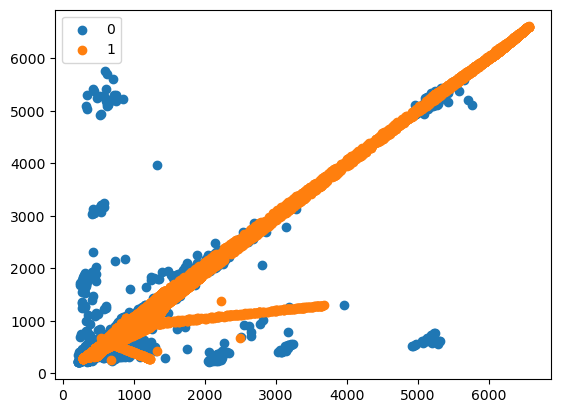

In [37]:
# Plot scatter points for each label in y
unique_labels = y.unique()
for label in unique_labels:
    row_ix = y[y == label].index
    plt.scatter(X.loc[row_ix, X.columns[0]], X.loc[row_ix, X.columns[1]], label=str(label))
plt.legend()
plt.show()

# scatter plot of examples by class label
#for label, _ in counter.items():
#	row_ix = where(y == label)[0]
#	pyplot.scatter(X[row_ix, 0], X[row_ix, 1], label=str(label))
#pyplot.legend()
#pyplot.show()

In [38]:
# borderline-SMOTE with SVM for imbalanced dataset
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import SVMSMOTE
from matplotlib import pyplot
from numpy import where

# define dataset
#X, y = make_classification(n_samples=10000, n_features=2, n_redundant=0,
#	n_clusters_per_class=1, weights=[0.99], flip_y=0, random_state=1)
# File path
csv_file_path = r"C:\Users\olufe\projects\Journal\dataset\HomeA_unsupervised_sim_combined_data.csv"

# Load the data from the CSV file
data = pd.read_csv(csv_file_path)

# Extract features (X) and target labels (y) from the loaded data
X = data.drop(columns=["Label"])  # Replace "target_column_name" with the actual column name for the target variable
y = data["Label"]  # Replace "target_column_name" with the actual column name for the target variable

# Print the extracted values of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (35330, 1380)
y shape: (35330,)


In [39]:
# summarize class distribution
counter = Counter(y)
print(counter)

Counter({0: 35186, 1: 144})


In [40]:
# transform the dataset
oversample = SVMSMOTE()
X, y = oversample.fit_resample(X, y)

In [41]:
# summarize the new class distribution
counter = Counter(y)
print(counter)

Counter({0: 35186, 1: 16146})


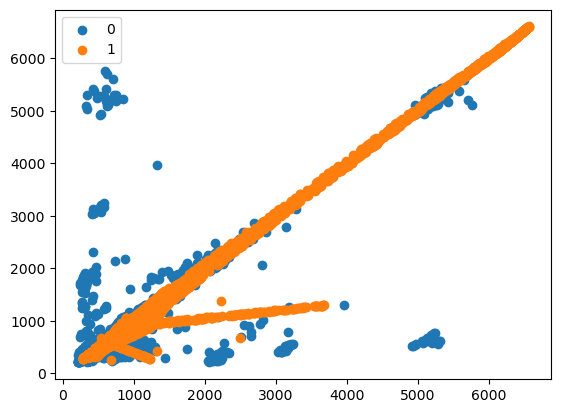

In [42]:
# Plot scatter points for each label in y
unique_labels = y.unique()
for label in unique_labels:
    row_ix = y[y == label].index
    plt.scatter(X.loc[row_ix, X.columns[0]], X.loc[row_ix, X.columns[1]], label=str(label))
plt.legend()
plt.show()

# scatter plot of examples by class label
#for label, _ in counter.items():
#	row_ix = where(y == label)[0]
#	pyplot.scatter(X[row_ix, 0], X[row_ix, 1], label=str(label))
#pyplot.legend()
#pyplot.show()